<div style="border-top: 4px solid #b85300; border-bottom: 1px solid #b85300; padding: 36px 0 28px; margin-bottom: 4px;">
  <h1 style="font-family: 'Palatino Linotype', Palatino, 'Book Antiqua', serif; font-size: 2.2em; color: #000000; margin: 0 0 10px; font-weight: 700; letter-spacing: 0.5px;">Análisis de Componentes Principales (PCA) Multidominio</h1>
  <p style="font-family: 'Palatino Linotype', Palatino, 'Book Antiqua', serif; font-size: 1.05em; color: #000000; margin: 0; font-style: italic;">Asignación: Reducción de Dimensionalidad</p>
</div>

<div style="margin: 32px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #000000; text-transform: uppercase; letter-spacing: 1.5px;">CONFIGURACIÓN</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000000; margin: 4px 0 0; font-weight: 600;">Librerías</h2>
</div>

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import scripts.Dataset_1 as usa_cars
import scripts.Dataset_2 as telco_customer_churn
import scripts.Dataset_3 as country

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df1= pd.read_csv('data/USA_Cars_Dataset.csv')
df1.head()

,YEAR,Brand,Model,Size,(kW),CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),RATING,(km),TIME (h)
0,2012,MITSUBISHI,i-MiEV,SUBCOMPACT,49,16.9,21.4,18.7,1.9,2.4,2.1,8,100,7
1,2012,NISSAN,LEAF,MID-SIZE,80,19.3,23.0,21.1,2.2,2.6,2.4,3,117,7
2,2013,FORD,FOCUS ELECTRIC,COMPACT,107,19.0,21.1,20.0,2.1,2.4,2.2,9,122,4
3,2013,MITSUBISHI,i-MiEV,SUBCOMPACT,49,16.9,21.4,18.7,1.9,2.4,2.1,2,100,7
4,2013,NISSAN,LEAF,MID-SIZE,80,19.3,23.0,21.1,2.2,2.6,2.4,1,117,7


<div style="border-top: 1px solid #b85300; margin-top: 0; padding-top: 28px; margin-bottom: 2rem;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.72em; color: #000000; text-transform: uppercase; letter-spacing: 1.5px;">Dataset 1</span>
  <h1 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.85em; color: #000; margin: 6px 0 0; font-weight: 700;">USA Cars Dataset</h1>
</div>

<p style="font-size: 0.95em; color: #555; margin: 0 0 1.8rem; line-height: 1.7;">
El Scree Plot muestra la varianza explicada acumulada al incrementar el número de componentes principales en el análisis PCA.
</p>

<div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 10px; margin-bottom: 2rem;">
  <div style="background: #f5f5f5; border-radius: 8px; padding: 1rem; text-align: center;">
    <div style="font-size: 11px; color: #999; text-transform: uppercase; letter-spacing: 1px; margin-bottom: 6px;">PC 1</div>
    <div style="font-size: 1.6em; font-weight: 500;">60%</div>
    <div style="font-size: 11px; color: #b85300; margin-top: 4px;">+60pp</div>
  </div>
  <div style="background: #f5f5f5; border-radius: 8px; padding: 1rem; text-align: center;">
    <div style="font-size: 11px; color: #999; text-transform: uppercase; letter-spacing: 1px; margin-bottom: 6px;">PC 2</div>
    <div style="font-size: 1.6em; font-weight: 500;">81%</div>
    <div style="font-size: 11px; color: #b85300; margin-top: 4px;">+21pp</div>
  </div>
  <div style="background: #f5f5f5; border-radius: 8px; padding: 1rem; text-align: center; border: 1px solid #b85300;">
    <div style="font-size: 11px; color: #999; text-transform: uppercase; letter-spacing: 1px; margin-bottom: 6px;">PC 3</div>
    <div style="font-size: 1.6em; font-weight: 500;">89%</div>
    <div style="font-size: 11px; color: #b85300; margin-top: 4px;">+8pp</div>
  </div>
  <div style="background: #f5f5f5; border-radius: 8px; padding: 1rem; text-align: center; border: 1px solid #b85300;">
    <div style="font-size: 11px; color: #999; text-transform: uppercase; letter-spacing: 1px; margin-bottom: 6px;">PC 4</div>
    <div style="font-size: 1.6em; font-weight: 500;">96%</div>
    <div style="font-size: 11px; color: #b85300; margin-top: 4px;">+7pp</div>
  </div>
</div>

---

### Análisis por componente

<div style="display: flex; flex-direction: column; gap: 12px; margin-bottom: 2rem;">
  <div style="display: flex; gap: 14px;">
    <span style="font-family: 'Courier New', monospace; font-size: 0.72em; color: #b85300; text-transform: uppercase; letter-spacing: 1px; min-width: 36px; padding-top: 3px;">PC 1</span>
    <p style="margin: 0; font-size: 0.92em; color: #555; line-height: 1.6;">Una sola dimensión resume más de la mitad de la variabilidad del dataset, lo que indica alta correlación entre las variables originales.</p>
  </div>
  <div style="display: flex; gap: 14px;">
    <span style="font-family: 'Courier New', monospace; font-size: 0.72em; color: #b85300; text-transform: uppercase; letter-spacing: 1px; min-width: 36px; padding-top: 3px;">PC 2</span>
    <p style="margin: 0; font-size: 0.92em; color: #555; line-height: 1.6;">El segundo componente aporta la mayor ganancia marginal (+21pp), representando ya la mayor parte de la información relevante.</p>
  </div>
  <div style="display: flex; gap: 14px;">
    <span style="font-family: 'Courier New', monospace; font-size: 0.72em; color: #b85300; text-transform: uppercase; letter-spacing: 1px; min-width: 36px; padding-top: 3px;">PC 3</span>
    <p style="margin: 0; font-size: 0.92em; color: #555; line-height: 1.6;">La ganancia se reduce a +8pp, pero el modelo aún captura estructura importante del dataset con solo tres dimensiones.</p>
  </div>
  <div style="display: flex; gap: 14px;">
    <span style="font-family: 'Courier New', monospace; font-size: 0.72em; color: #b85300; text-transform: uppercase; letter-spacing: 1px; min-width: 36px; padding-top: 3px;">PC 4</span>
    <p style="margin: 0; font-size: 0.92em; color: #555; line-height: 1.6;">A partir de aquí la curva se aplana: agregar más componentes aporta rendimientos decrecientes.</p>
  </div>
</div>



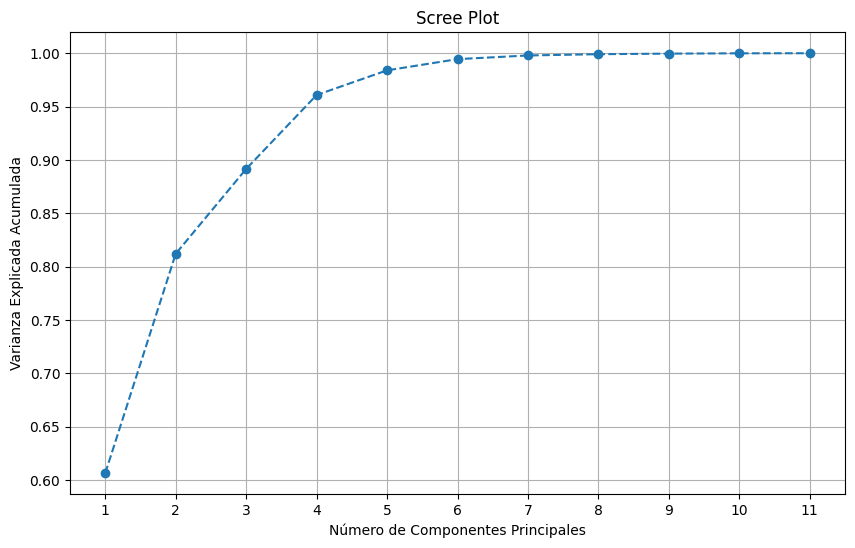

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scripts.Dataset_1 import Scree_Plot

df = pd.read_csv('data/USA_Cars_Dataset.csv')

# columnas numéricas
X = df.select_dtypes(include=np.number)

# escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
pca.fit(X_scaled)

# gráfico
Scree_Plot(pca)


---

### Conclusión

<p style="font-size: 0.92em; color: #555; line-height: 1.7;">
El Scree Plot presenta un <strong>codo visible entre los componentes 3 y 4</strong>, señal clásica del punto óptimo de reducción dimensional. Las 11 variables originales pueden comprimirse conservando entre el 89% y 96% de la información.
</p>

<div style="background: #f5f5f5; border-left: 2px solid #b85300; padding: 10px 16px; display: flex; align-items: center; justify-content: space-between; flex-wrap: wrap; gap: 8px; margin: 1rem 0;">
  <span style="font-size: 0.85em; color: #555;">Elección recomendada</span>
  <code style="font-family: 'Courier New', monospace; font-size: 0.88em;">PCA(n_components=4)</code>
  <span style="font-size: 0.78em; color: #999;">conserva ~96% de la varianza</span>
</div>

<p style="font-size: 0.82em; color: #999; margin-top: 10px; line-height: 1.5;">
Si se prioriza simplicidad, <code>n_components=3</code> (89%) también es una opción válida.
</p>

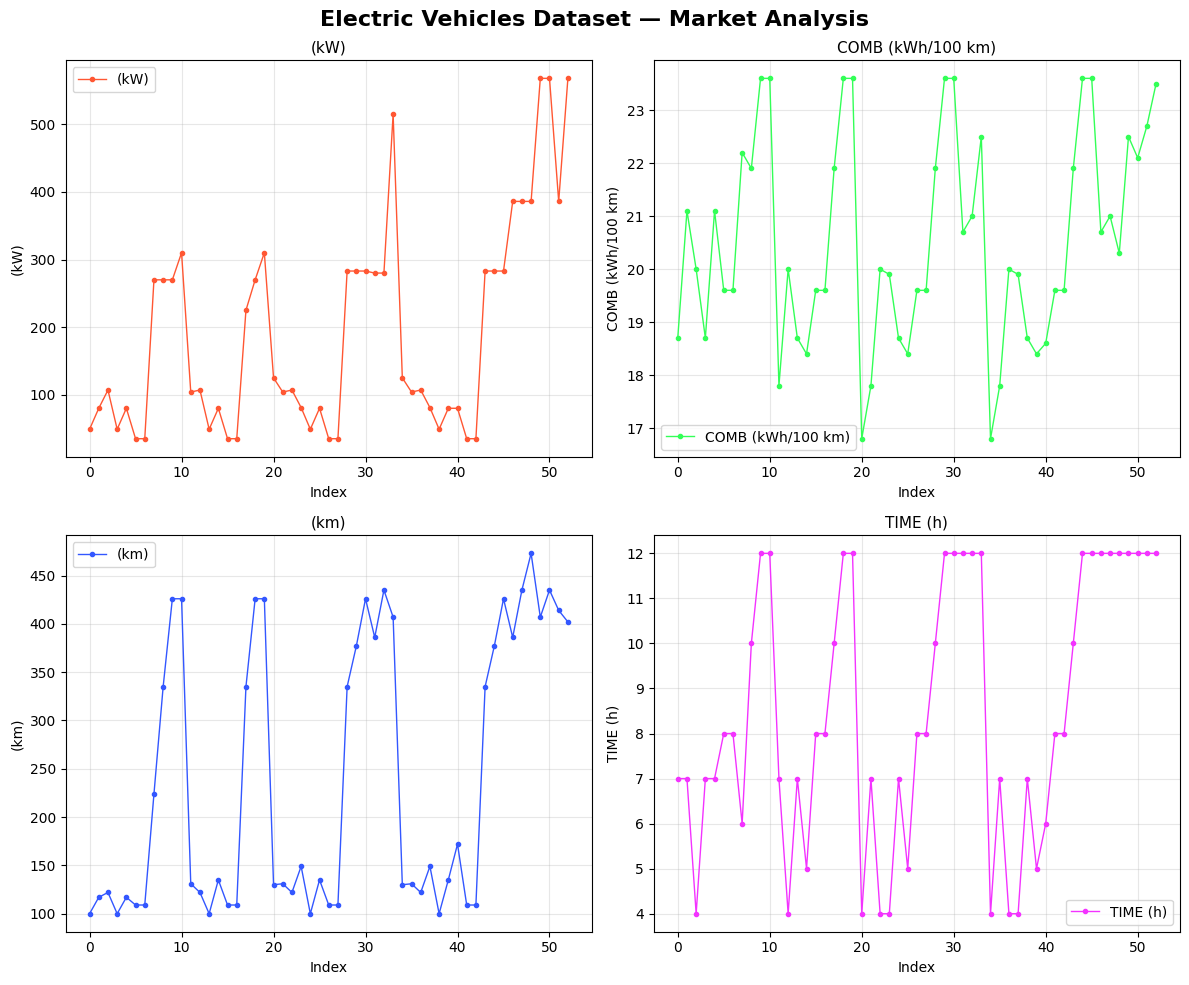

In [ ]:

df1= pd.read_csv('data/USA_Cars_Dataset.csv')

# Features numéricas para graficar
feature_names = ['(kW)', 'COMB (kWh/100 km)', '(km)', 'TIME (h)']
X = df1[feature_names]

current_year = 2024
colors = ['#FF5733', '#33FF57', '#3357FF', '#F333FF']

fig, axes = plt.subplots(figsize=(12, 10), nrows=2, ncols=2)
fig.suptitle('Electric Vehicles Dataset — Market Analysis', fontsize=16, fontweight='bold')

for i, (feature_name, feature_array) in enumerate(X.items()):
    ax = fig.axes[i]

    if feature_name == 'YEAR':
        feature_array = current_year - feature_array

    ax.plot(
        feature_array.values,
        label=feature_name,
        color=colors[i],
        marker='o',
        linewidth=1,
        markersize=3
    )
    ax.set_title(feature_name, fontsize=11)
    ax.set_xlabel('Index')
    ax.set_ylabel(feature_name)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ev_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
Se analiza un dataset de **53 vehículos eléctricos** registrados entre 2012 y 2016.  
El objetivo es explorar las principales variables que caracterizan el rendimiento y la autonomía de estos vehículos mediante visualización de datos.

**Variables analizadas:**
| Variable | Descripción |
|---|---|
| `(kW)` | Potencia del motor eléctrico |
| `COMB (kWh/100 km)` | Consumo combinado de energía |
| `(km)` | Autonomía de carga |
| `TIME (h)` | Tiempo de carga en horas |